In [11]:
DATA_DIR = "../../data"
MODELS_DIR = "../../models"

In [12]:
import pandas as pd

df = pd.read_csv(f"{DATA_DIR}/preprocessed/train.csv")

display(df)

,elo_diff,winrate_10_diff,winrate_30_diff,experience_diff,rank_diff,h2h_winrate,team_1_wins
0,-0.142716,-0.049294,-0.066090,-0.110257,0.233918,-0.076338,1
1,-0.046395,2.760416,3.461053,-0.105192,0.047774,-0.076338,1
2,-0.142716,-0.049294,-0.066090,-0.110257,0.081619,-0.076338,1
3,-0.142716,-0.049294,-0.066090,-0.110257,-0.002992,-0.076338,0
4,-0.335358,-2.859004,-3.593233,-0.110257,-0.002992,-1.544189,0
...,...,...,...,...,...,...,...
41196,1.077886,1.917503,0.874482,1.054633,-0.138369,0.155428,1
41197,0.253357,0.512648,0.521767,1.647207,-0.646034,0.857750,1
41198,2.155184,1.917503,0.404196,3.429995,-0.222980,1.391514,1
41199,2.193711,2.198474,0.521767,3.429995,-0.222980,1.391514,1


In [13]:
target = "team_1_wins"

X = df.drop(target, axis=1)
y = df[target]

In [14]:
import os

import mlflow
from dotenv import load_dotenv

load_dotenv()

os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("MLFLOW_S3_ACCESS_KEY", "")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("MLFLOW_S3_SECRET_KEY", "")

mlflow.set_tracking_uri(
    os.getenv("MLFLOW_TRACKING_URI", "https://mlflow.internal.roxxas96.net")
)
experiment = mlflow.set_experiment(
    os.getenv("MLFLOW_EXPERIMENT_NAME", "cs-go-match-predictor-local")
)

print(f"Experiment id: {experiment.experiment_id}")
print(f"Experiment name: {experiment.name}")

Experiment id: 1
Experiment name: cs-go-match-predictor-local


In [15]:
import numpy as np
import tensorflow as tf
import tf2onnx
import onnx
from keras import callbacks, layers, metrics, models, optimizers
from mlflow.models import infer_signature
from sklearn.model_selection import train_test_split

learning_rate = 0.01
dense_1_units = 64
dense_2_units = 16
dropout = 0.3
batch_size = 128
epoch = 100
validation_split = 0.2
patience = 10

model = models.Sequential(
    [
        layers.Input(shape=(X.shape[1],)),
        layers.Dense(dense_1_units, activation="relu"),
        layers.Dropout(dropout),
        layers.BatchNormalization(),
        layers.Dense(dense_2_units, activation="relu"),
        layers.Dropout(dropout),
        layers.BatchNormalization(),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss="binary_crossentropy",
    metrics=["accuracy", metrics.AUC(name="auc")],
)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=validation_split, random_state=42
)

train_ds = tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
val_ds = tf.data.Dataset.from_tensor_slices((X_val.values, y_val.values))

train_ds = train_ds.batch(batch_size)
val_ds = val_ds.batch(batch_size)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

with mlflow.start_run():
    mlflow.log_params(
        {
            "learning_rate": learning_rate,
            "dense_1_units": dense_1_units,
            "dense_2_units": dense_2_units,
            "dropout": dropout,
            "batch_size": batch_size,
            "epochs": epoch,
            "validation_split": validation_split,
            "patience": patience,
            "optimizer": "Adam",
            "loss": "binary_crossentropy",
        }
    )

    train_dataset = mlflow.data.from_pandas(  # type: ignore
        X_train.assign(target=y_train), targets="target"
    )  # type: ignore
    val_dataset = mlflow.data.from_pandas(X_val.assign(target=y_val), targets="target")  # type: ignore

    mlflow.log_input(train_dataset, context="training")
    mlflow.log_input(val_dataset, context="validation")

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epoch,
        callbacks=[
            callbacks.EarlyStopping(
                monitor="val_auc",
                patience=patience,
                restore_best_weights=True,
            )
        ],
    )

    for epoch_idx in range(len(history.history["loss"])):
        for metric_name, values in history.history.items():
            mlflow.log_metric(metric_name, values[epoch_idx], step=epoch_idx)

    mlflow.log_metric("best_val_loss", np.min(history.history["val_loss"]))
    mlflow.log_metric("best_val_auc", np.max(history.history["val_auc"]))

    input_example = X_train.iloc[:5].astype(np.float32).to_numpy()
    predictions = model.predict(input_example)

    signature = infer_signature(input_example, predictions)

    print(os.environ["AWS_ACCESS_KEY_ID"])

    mlflow.tensorflow.log_model(  # type: ignore
        model,
        name="tf_model",  # replaces deprecated artifact_path
        signature=signature,
        input_example=input_example,
        tags={"runtime": "tensorflow"},
    )

    model.save(f"{MODELS_DIR}/model.keras")

    spec = (tf.TensorSpec((None, len(X.columns)), tf.float32, name="input"),)

    @tf.function(input_signature=spec)
    def model_fn(x):
        return model(x)

    onnx_path = f"{MODELS_DIR}/model/cs-go-match-predictor/1/model.onnx"

    tf2onnx.convert.from_function(
        model_fn,
        opset=17,
        output_path=onnx_path,
        input_signature=spec,
    )

    onnx_model = onnx.load(onnx_path)

    mlflow.onnx.log_model(  # type: ignore
        onnx_model, name="onnx_model", tags={"runtime": "onnx"}
    )

Epoch 1/100


/Users/gomez/Code/cs-go-match-predictor/notebooks/03_train_model_local/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7311 - auc: 0.8012 - loss: 0.5452 - val_accuracy: 0.7502 - val_auc: 0.8249 - val_loss: 0.5134
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - accuracy: 0.7406 - auc: 0.8117 - loss: 0.5307 - val_accuracy: 0.7502 - val_auc: 0.8253 - val_loss: 0.5112
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - accuracy: 0.7409 - auc: 0.8124 - loss: 0.5296 - val_accuracy: 0.7532 - val_auc: 0.8266 - val_loss: 0.5087
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - accuracy: 0.7405 - auc: 0.8133 - loss: 0.5287 - val_accuracy: 0.7505 - val_auc: 0.8264 - val_loss: 0.5092
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - accuracy: 0.7414 - auc: 0.8139 - loss: 0.5278 - val_accuracy: 0.7525 - val_auc: 0.8268 - val_loss: 0.5086
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 0.7419 - auc: 0.8140 - loss: 0.5282 - val_accuracy: 0.7521 - val_auc: 0.8274 - val_loss: 0.5081
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━

2026/05/02 17:37:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/gomez/Code/cs-go-match-predictor/notebooks/03_train_model_local


E6NTGOUJR97LUF7JU5WL


2026/05/02 17:37:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/gomez/Code/cs-go-match-predictor/notebooks/03_train_model_local
2026/05/02 17:37:21 INFO mlflow.utils.environment: Detected uv project at /Users/gomez/Code/cs-go-match-predictor/notebooks/03_train_model_local. Attempting to export requirements via 'uv export'.
2026/05/02 17:37:21 INFO mlflow.utils.uv_utils: Exported 128 dependencies via uv
2026/05/02 17:37:21 INFO mlflow.utils.environment: Successfully exported 128 requirements from uv project. Skipping package capture based inference.
2026/05/02 17:37:21 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - boto3 (current: 1.42.90, required: boto3==1.42.93)
 - botocore (current: 1.42.90, required: botocore==1.42.93)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and instal

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


I0000 00:00:1777736242.529565 3853338 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777736242.529684 3853338 single_machine.cc:376] Starting new session
I0000 00:00:1777736242.560346 3853338 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1777736242.560418 3853338 single_machine.cc:376] Starting new session
2026/05/02 17:37:22 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/gomez/Code/cs-go-match-predictor/notebooks/03_train_model_local
2026/05/02 17:37:23 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/gomez/Code/cs-go-match-predictor/notebooks/03_train_model_local
2026/05/02 17:37:23 INFO mlflow.utils.environment: Detected uv project at /Users/gomez/Code/cs-go-match-predic

🏃 View run upset-skunk-860 at: https://mlflow.internal.roxxas96.net/#/experiments/1/runs/3a852101f4f746bdb5b8007f1e65b78f
🧪 View experiment at: https://mlflow.internal.roxxas96.net/#/experiments/1


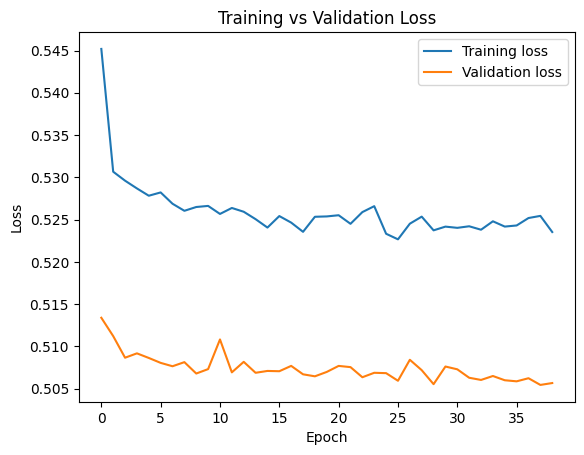

In [16]:
import matplotlib.pyplot as plt

loss = history.history["loss"]  # type: ignore
val_loss = history.history["val_loss"]  # type: ignore

plt.figure()
plt.plot(loss, label="Training loss")
plt.plot(val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [17]:
X_train_df = pd.DataFrame(X_train)
y_train_df = pd.Series(y_train, name="team_1_wins")

train_ds = pd.concat([X_train_df, y_train_df], axis=1)

X_val_df = pd.DataFrame(X_val)
y_val_df = pd.Series(y_val, name="team_1_wins")

val_ds = pd.concat([X_val_df, y_val_df], axis=1)

train_ds.to_csv(f"{DATA_DIR}/train/train.csv", index=False)
val_ds.to_csv(f"{DATA_DIR}/train/val.csv", index=False)